# 🧪 Analíticas de sangre (tabular) — v2.2 (exprimido al máximo · CPU · modelo independiente)
## TFM · Módulo Tabular (Laboratorio) · Universidad de Salamanca

---

Versión que **mejora todo lo posible** dentro del techo real de la señal tabular (≈0.67-0.69; el EDA ya lo anticipaba).
Modelo **independiente** (sin fusión). TabPFN por **nube** (`tabpfn-client`).

## 🆙 Qué añade respecto a v2.1

| Mejora | Detalle |
|---|---|
| **Ingeniería de variables clínicas** | ratios con sentido fisiológico: **BUN/Creatinina** (función renal), **Neutrófilos/Linfocitos** (inflamación), **RDW×Edad**. Calculados desde el valor bruto. |
| **Tuning de TODOS los modelos** | Optuna por cada arquitectura (XGBoost, LightGBM, LogReg, MLP), no solo del mejor → comparación justa con cada uno en su punto óptimo. |
| **ENSEMBLE por promedio (blending)** | se promedian las probabilidades de los modelos → suele dar el **mejor macro** (modelos algo descorrelacionados). Es un promedio, **no un meta-modelo** (no es stacking). |
| **Selección final entre todos + ensemble** | el "mejor" puede ser un modelo individual o el ensemble; se entrena/recompone en serio y se evalúa en test. |

Se mantiene de v2.1: **sin data leakage** (imputación/escalado por fold), **sin `cxr_view`**, raw/percentil por familia,
flags de missingness (MNAR), enmascarado + negativos derivados de *No Finding*, desequilibrio por etiqueta, **AUC-ROC macro**.

## ⏱️ Coste (CPU): ~1 hora (tuning de los 4 modelos + K=5 + TabPFN nube). "Complejo justo".

## 🎯 Expectativa honesta

La señal tabular tiene techo (~0.67-0.69). El ensemble + ratios suele aportar **+0.005-0.015** sobre el mejor individual.
No esperes saltos grandes: la información de las analíticas no da para más; su valor es como **modalidad complementaria**.


In [2]:
# CELDA 1 · DEPENDENCIAS
import subprocess, sys
try:
    import torch  # noqa: F401
except ImportError:
    subprocess.run([sys.executable,"-m","pip","install","torch","--index-url","https://download.pytorch.org/whl/cpu","-q"], check=True)
for pkg in ["xgboost","lightgbm","scikit-learn","optuna","pandas","numpy","matplotlib","seaborn","tqdm"]:
    subprocess.run([sys.executable,"-m","pip","install",pkg,"-q"], check=True)
try:
    subprocess.run([sys.executable,"-m","pip","install","tabpfn-client","-q"], check=True); print("tabpfn-client (nube) instalado.")
except Exception as ex:
    print("tabpfn-client no se pudo instalar (se omitirá):", ex)
print("Dependencias instaladas.")


tabpfn-client (nube) instalado.
Dependencias instaladas.


In [3]:
# CELDA 2 · IMPORTS / SEMILLAS / DISPOSITIVO
import os, gc, json, time, copy, random, warnings, functools
from pathlib import Path
from collections import Counter
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from tqdm.auto import tqdm
import torch, torch.nn as nn, torch.nn.functional as F
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             confusion_matrix, roc_curve, precision_recall_curve)
import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING); warnings.filterwarnings("ignore")
try:
    import tabpfn_client
    from tabpfn_client import TabPFNClassifier
    _tok=os.environ.get("TABPFN_TOKEN")
    if _tok:
        try: tabpfn_client.set_access_token(_tok)
        except Exception: pass
    TABPFN_OK=True
except Exception as _e:
    print("tabpfn-client no disponible:", _e); TABPFN_OK=False
SEED=42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.set_num_threads(4); DEVICE=torch.device("cpu")
print(f"xgboost {xgb.__version__} · lightgbm {lgb.__version__} · TabPFN: {TABPFN_OK}")


c:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


xgboost 2.1.4 · lightgbm 4.6.0 · TabPFN: True


In [4]:
# CELDA 3 · RUTAS, ETIQUETAS Y CONSTANTES (v2.2)
BASE=Path(r"C:\TFM\1.Opción - Symile Mimic\symile-mimic-a-multimodal-clinical-dataset-of-chest-x-rays-electrocardiograms-and-blood-labs-from-mimic-iv-1.0.0")
CSV_DIR=BASE/"data_csv"/"clean"
TRAIN_CSV,VAL_CSV,TEST_CSV=CSV_DIR/"train_clean.csv",CSV_DIR/"val_clean.csv",CSV_DIR/"test_clean.csv"
OUTPUT_DIR=Path("outputs_labs_tabular_v2_2").resolve(); OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
FIG_DIR=OUTPUT_DIR/"figuras"; FIG_DIR.mkdir(parents=True,exist_ok=True)
print("Salidas en:", OUTPUT_DIR)
LABELS=["Atelectasis","Cardiomegaly","Edema","Lung Opacity","No Finding","Pleural Effusion"]
N_LABELS=len(LABELS); NO_FINDING="No Finding"
PATHOLOGY_LABELS=[l for l in LABELS if l!=NO_FINDING]; CORE_LABELS=["Cardiomegaly","Edema","Pleural Effusion"]
DERIVE_NEGATIVES_FROM_EXCLUSIVITY=True
FLAG_THRESH=0.02
K_COMPARE=5
TUNE_GBM=30; TUNE_LOGREG=20; TUNE_MLP=20      # tuning por modelo (complejo justo)
USE_TABPFN=TABPFN_OK; TABPFN_MAX=4000; TABPFN_MAX_FINAL=6000
GENDER_MAP={0:0,1:1,"0":0,"1":1,"M":1,"F":0}
RACE_MAP={"UNKNOWN":0,"WHITE":1,"BLACK":2,"ASIAN":3,"HISPANIC_LATINO":4,"OTHER_KNOWN":0}
ADMISSION_MAP={"SCHEDULED":0,"EMERGENCY":1,"OBSERVATION":2,"URGENT":3}
ADM_LOC_MAP={"EMERGENCY_ROOM":0,"REFERRAL":1,"TRANSFER":2,"INTRA_HOSPITAL":3}
RACE_ONEHOT=5
LAB_MEANING={
 "urea_nitrogen":"función renal/gravedad","albumin":"proteína; baja en efusiones/ICC","rdw":"anisocitosis; fallo cardíaco",
 "creatinine":"función renal","lymphocytes_pct":"inflamación/inmunidad","hemoglobin":"anemia","hematocrit":"anemia",
 "rbc":"masa eritrocitaria","mch":"índice eritrocitario","mchc":"índice eritrocitario","mcv":"índice eritrocitario",
 "nrbc_abs":"estrés medular","pt":"coagulación","inr_pt":"coagulación/hepático","ptt":"coagulación",
 "phosphate":"metabólico","calcium_total":"metabólico","magnesium":"metabólico","sodium":"electrolito/renal",
 "potassium":"electrolito/renal","chloride":"electrolito","bicarbonate":"ácido-base","anion_gap":"ácido-base",
 "base_excess":"ácido-base","ph":"ácido-base","pco2":"gases","po2":"gases","calculated_total_co2":"ácido-base",
 "lactate":"hipoperfusión","glucose":"metabólico","alt":"hepático","ast":"hepático",
 "alkaline_phosphatase":"hepático/óseo","bilirubin_total":"hepático","fibrinogen":"coagulación/inflamación",
 "wbc_count":"inflamación","neutrophils_pct":"inflamación","monocytes_pct":"inmunidad",
 "basophils_pct":"inmunidad","eosinophils_pct":"alergia/inmunidad","platelet_count":"hemostasia"}
def readable(col):
    name,code=col.rsplit("_",1); pretty=name.replace("_"," ").title(); mn=LAB_MEANING.get(name,"")
    return f"{pretty} ({code})"+(f" – {mn}" if mn else "")
print("Constantes listas (v2.2).")


Salidas en: C:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\notebooks\outputs_labs_tabular_v2_2
Constantes listas (v2.2).


In [5]:
# CELDA 4 · CARGA DE CSV
df_train=pd.read_csv(TRAIN_CSV,sep=";"); df_val=pd.read_csv(VAL_CSV,sep=";"); df_test=pd.read_csv(TEST_CSV,sep=";")
DEMO=["subject_id","hadm_id","cxr_path","ecg_path","age","gender","race","admission_type","admission_location","cxr_view","hours_adm_to_cxr"]
RAW_LABS=[c for c in df_train.columns if c not in LABELS and c not in DEMO and "pctile" not in c]
PCT_LABS=[c for c in df_train.columns if "pctile" in c]
print(f"train={len(df_train)} val={len(df_val)} test={len(df_test)} | raw={len(RAW_LABS)} percentil={len(PCT_LABS)}")


train=10000 val=750 test=464 | raw=41 percentil=41


In [6]:
# CELDA 5 · OBJETIVOS (masking + negativos derivados)
def build_targets(df,uncertainty_policy="zeros",derive=DERIVE_NEGATIVES_FROM_EXCLUSIVITY,verbose=False):
    raw=df[LABELS].to_numpy(dtype=float); N=raw.shape[0]
    labels=np.zeros((N,N_LABELS),np.float32); mask=np.zeros((N,N_LABELS),np.float32)
    mask[~np.isnan(raw)]=1.0; labels[raw==1]=1.0
    unc=(raw==-1); labels[unc]=1.0 if uncertainty_policy=="ones" else 0.0
    nf=LABELS.index(NO_FINDING); pc=[j for j in range(N_LABELS) if j!=nf]; n_dp=n_dn=0
    if derive:
        nfp=(raw[:,nf]==1)
        for j in pc:
            f=nfp&np.isnan(raw[:,j]); labels[f,j]=0.0; mask[f,j]=1.0; n_dp+=int(f.sum())
        ap=(raw[:,pc]==1).any(1); fn=ap&np.isnan(raw[:,nf]); labels[fn,nf]=0.0; mask[fn,nf]=1.0; n_dn=int(fn.sum())
    if verbose: print(f"   Neg. derivados patologías={n_dp:,} · No Finding={n_dn:,}")
    return labels,mask
y_train,m_train=build_targets(df_train,"zeros",verbose=True)
y_val,m_val=build_targets(df_val,"zeros"); y_test,m_test=build_targets(df_test,"zeros")


   Neg. derivados patologías=6,091 · No Finding=7,691


In [7]:
# CELDA 6 · FEATURES + INGENIERÍA CLÍNICA (sin leakage)
train_miss=df_train[RAW_LABS].isna().mean()
FLAG_LABS=[c for c in RAW_LABS if train_miss[c]>FLAG_THRESH]
def _col(key):
    for c in RAW_LABS:
        if c.startswith(key+"_") or c==key: return c
    return None
C_UREA=_col("urea_nitrogen"); C_CREAT=_col("creatinine"); C_NEUT=_col("neutrophils_pct"); C_LYMPH=_col("lymphocytes_pct"); C_RDW=_col("rdw")
def clinical_ratios(df):
    out=[]; names=[]
    def g(c): return df[c].to_numpy(np.float32) if c else np.full(len(df),np.nan,np.float32)
    urea,creat,neut,lymph,rdw=g(C_UREA),g(C_CREAT),g(C_NEUT),g(C_LYMPH),g(C_RDW)
    age=df["age"].astype(float).to_numpy(np.float32)
    out.append((urea/(creat+1e-6))[:,None]); names.append("BUN/Creatinina (ratio renal)")
    out.append((neut/(lymph+1e-6))[:,None]); names.append("Neutrófilos/Linfocitos (ratio inflam.)")
    out.append((rdw*age/100.0)[:,None]); names.append("RDW×Edad (riesgo cardio)")
    return np.hstack(out).astype(np.float32), names
RATIO_tr,RATIO_NAMES=clinical_ratios(df_train)
print(f"Ratios clínicos añadidos: {RATIO_NAMES}")
print(f"Flags de missingness: {len(FLAG_LABS)}/{len(RAW_LABS)}")

def build_demo(df):
    N=len(df); cols=[]; names=[]
    cols.append(df["age"].astype(float).to_numpy()[:,None]); names.append("Edad")
    cols.append(df["gender"].map(lambda v:float(GENDER_MAP.get(v,0))).to_numpy()[:,None]); names.append("Sexo")
    def onehot(series,mp,pref):
        M=np.zeros((N,max(mp.values())+1),np.float32)
        for i,v in enumerate(series): M[i,mp.get(str(v).upper(),0)]=1.0
        return M,[f"{pref}={k}" for k,_ in sorted(mp.items(),key=lambda x:x[1])][:M.shape[1]]
    for col,mp,pref in [("race",RACE_MAP,"Raza"),("admission_type",ADMISSION_MAP,"Ingreso"),("admission_location",ADM_LOC_MAP,"Lugar")]:
        M,nm=onehot(df[col],mp,pref); cols.append(M); names+=nm
    cols.append(df["hours_adm_to_cxr"].astype(float).to_numpy()[:,None]); names.append("Horas ingreso→CXR")
    return np.hstack(cols).astype(np.float32), names
DEMO_M_tr,DEMO_NAMES=build_demo(df_train)
def flags(df): return df[FLAG_LABS].isna().astype(np.float32).to_numpy()
def build_tree(df,demo): return np.hstack([df[RAW_LABS].to_numpy(np.float32), clinical_ratios(df)[0], flags(df), demo])
def build_dense_raw(df,demo): return np.hstack([df[PCT_LABS].to_numpy(np.float32), clinical_ratios(df)[0], flags(df), demo])
TREE_tr=build_tree(df_train,DEMO_M_tr); TREE_te=build_tree(df_test,build_demo(df_test)[0]); TREE_vl=build_tree(df_val,build_demo(df_val)[0])
DENSE_tr=build_dense_raw(df_train,DEMO_M_tr); DENSE_te=build_dense_raw(df_test,build_demo(df_test)[0]); DENSE_vl=build_dense_raw(df_val,build_demo(df_val)[0])
TREE_NAMES=[readable(c) for c in RAW_LABS]+RATIO_NAMES+[f"falta:{c.rsplit('_',1)[0].replace('_',' ').title()}" for c in FLAG_LABS]+DEMO_NAMES
def dense_fit(idx):
    imp=SimpleImputer(strategy="median").fit(DENSE_tr[idx]); sc=StandardScaler().fit(imp.transform(DENSE_tr[idx])); return imp,sc
def dense_tx(imp,sc,X): return sc.transform(imp.transform(X)).astype(np.float32)
print(f"TREE={TREE_tr.shape} · DENSE={DENSE_tr.shape} (incluye {len(RATIO_NAMES)} ratios) · imputación/escalado POR FOLD")


Ratios clínicos añadidos: ['BUN/Creatinina (ratio renal)', 'Neutrófilos/Linfocitos (ratio inflam.)', 'RDW×Edad (riesgo cardio)']
Flags de missingness: 24/41
TREE=(10000, 84) · DENSE=(10000, 84) (incluye 3 ratios) · imputación/escalado POR FOLD


In [8]:
# CELDA 7 · MÉTRICAS
def multilabel_metrics(probs,labels,mask,thresholds=None):
    if thresholds is None: thresholds={l:0.5 for l in LABELS}
    res={}
    for j,l in enumerate(LABELS):
        s=mask[:,j]==1; yt=labels[s,j]; yp=probs[s,j]; npos=int(yt.sum()); nneg=int((1-yt).sum())
        thr=thresholds.get(l,0.5); pred=(yp>=thr).astype(float)
        if npos>=2 and nneg>=2: auc=roc_auc_score(yt,yp); ap=average_precision_score(yt,yp)
        else: auc=ap=float("nan")
        tp=int(((pred==1)&(yt==1)).sum()); tn=int(((pred==0)&(yt==0)).sum())
        fp=int(((pred==1)&(yt==0)).sum()); fn=int(((pred==0)&(yt==1)).sum())
        res[l]={"AUC":auc,"AP":ap,"F1":f1_score(yt,pred,zero_division=0),"sens":tp/max(tp+fn,1),"spec":tn/max(tn+fp,1),
                "n_pos":npos,"n_neg":nneg,"thr":thr,"TP":tp,"TN":tn,"FP":fp,"FN":fn}
    def mac(g):
        v=[res[l]["AUC"] for l in g if not np.isnan(res[l]["AUC"])]; return float(np.mean(v)) if v else float("nan")
    res["macro_AUC_core"]=mac(CORE_LABELS); res["macro_AUC_path"]=mac(PATHOLOGY_LABELS); return res
def best_thresholds_by_f1(probs,labels,mask,grid=None):
    if grid is None: grid=np.linspace(0.05,0.95,37)
    thr={}
    for j,l in enumerate(LABELS):
        s=mask[:,j]==1; yt=labels[s,j]; yp=probs[s,j]
        if yt.sum()<2: thr[l]=0.5; continue
        bf,bt=-1,0.5
        for t in grid:
            f=f1_score(yt,(yp>=t).astype(float),zero_division=0)
            if f>bf: bf,bt=f,t
        thr[l]=float(bt)
    return thr
print("Métricas listas.")


Métricas listas.


In [9]:
# CELDA 8 · MLP PROFUNDO multilabel enmascarado
class MaskedBCE(nn.Module):
    def __init__(s,pos_weight,focal=False,gamma=2.0):
        super().__init__(); s.register_buffer("pw",pos_weight); s.focal=focal; s.g=gamma
    def forward(s,logits,labels,mask):
        pw=s.pw.to(logits.device)
        bce=F.binary_cross_entropy_with_logits(logits,labels,pos_weight=pw,reduction="none")
        if s.focal:
            p=torch.sigmoid(logits); pt=labels*p+(1-labels)*(1-p); bce=((1-pt)**s.g)*bce
        bce=bce*mask; return bce.sum()/mask.sum().clamp(min=1e-8)
class TabMLP(nn.Module):
    def __init__(s,d,hidden=512,dropout=0.3):
        super().__init__(); h2,h3=hidden//2,hidden//4
        s.net=nn.Sequential(nn.Linear(d,hidden),nn.BatchNorm1d(hidden),nn.ReLU(inplace=True),nn.Dropout(dropout),
                            nn.Linear(hidden,h2),nn.BatchNorm1d(h2),nn.ReLU(inplace=True),nn.Dropout(dropout),
                            nn.Linear(h2,h3),nn.BatchNorm1d(h3),nn.ReLU(inplace=True),nn.Dropout(dropout*0.6),
                            nn.Linear(h3,N_LABELS))
    def forward(s,x): return s.net(x)
def dyn_pos_weight(y,m,clip=10.0):
    w=np.ones(N_LABELS,np.float32)
    for j in range(N_LABELS):
        s=m[:,j]==1; pos=(y[s,j]==1).sum(); neg=(y[s,j]==0).sum(); w[j]=np.clip(neg/max(pos,1),1/clip,clip)
    return torch.tensor(w,dtype=torch.float32)
def train_mlp(Xtr,ytr,mtr,Xva,yva,mva,cfg,epochs=150,patience=15):
    crit=MaskedBCE(dyn_pos_weight(ytr,mtr),focal=cfg.get("focal",False)).to(DEVICE)
    model=TabMLP(Xtr.shape[1],cfg.get("hidden",512),cfg.get("dropout",0.3)).to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=cfg.get("lr",8e-4),weight_decay=cfg.get("wd",1e-4))
    sched=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=epochs,eta_min=1e-7)
    Xt=torch.tensor(Xtr); Yt=torch.tensor(ytr); Mt=torch.tensor(mtr); n=len(Xt); bs=256
    best,bs_state,wait=-1.0,None,0
    for ep in range(epochs):
        model.train(); perm=torch.randperm(n)
        for i in range(0,n,bs):
            idx=perm[i:i+bs]
            if len(idx)<2: continue
            opt.zero_grad(); loss=crit(model(Xt[idx].to(DEVICE)),Yt[idx].to(DEVICE),Mt[idx].to(DEVICE))
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step()
        sched.step()
        with torch.no_grad():
            model.eval(); pv=torch.sigmoid(model(torch.tensor(Xva).to(DEVICE))).cpu().numpy()
        sc=multilabel_metrics(pv,yva,mva)["macro_AUC_path"]
        if not np.isnan(sc) and sc>best+1e-4: best,bs_state,wait=sc,copy.deepcopy(model.state_dict()),0
        else:
            wait+=1
            if wait>=patience: break
    if bs_state is not None: model.load_state_dict(bs_state)
    with torch.no_grad():
        model.eval(); pv=torch.sigmoid(model(torch.tensor(Xva).to(DEVICE))).cpu().numpy()
    return model, pv
print("MLP listo.")


MLP listo.


In [10]:
# CELDA 9 · One-vs-rest + modelos (con config por modelo)
def ovr_fit_predict(make_clf, Xtr, ytr, mtr, Xva, use_spw=True):
    probs=np.full((len(Xva),N_LABELS),0.5,np.float32)
    for j in range(N_LABELS):
        sel=mtr[:,j]==1; Xj=Xtr[sel]; yj=ytr[sel,j]
        if len(np.unique(yj))<2:
            probs[:,j]=float(yj.mean()) if len(yj) else 0.5; continue
        spw=(yj==0).sum()/max((yj==1).sum(),1)
        clf=make_clf(spw if use_spw else None); clf.fit(Xj,yj); probs[:,j]=clf.predict_proba(Xva)[:,1]
    return probs
def make_xgb(spw,cfg=None):
    p=dict(n_estimators=800,max_depth=5,learning_rate=0.03,subsample=0.8,colsample_bytree=0.8,min_child_weight=2,reg_lambda=1.5,tree_method="hist",eval_metric="logloss",n_jobs=4,random_state=SEED)
    if cfg: p.update(cfg)
    return xgb.XGBClassifier(scale_pos_weight=spw,**p)
def make_lgb(spw,cfg=None):
    p=dict(n_estimators=800,num_leaves=63,learning_rate=0.03,subsample=0.8,colsample_bytree=0.8,min_child_samples=20,reg_lambda=1.5,n_jobs=4,random_state=SEED,verbosity=-1)
    if cfg: p.update(cfg)
    return lgb.LGBMClassifier(scale_pos_weight=spw,**p)
def make_logreg(spw,cfg=None):
    return LogisticRegression(max_iter=3000,class_weight="balanced",C=(cfg or {}).get("C",1.0),n_jobs=4)
def make_tabpfn(spw=None,n_ens=4):
    return TabPFNClassifier()   # cliente NUBE (token en celda 2). NO incluyas tu clave aquí.

def predict_model(name, tr, va, Xd_tr, Xd_va, cfgs):
    cfg=cfgs.get(name,{})
    if name=="XGBoost":  return ovr_fit_predict(lambda spw: make_xgb(spw,cfg), TREE_tr[tr], y_train[tr], m_train[tr], TREE_tr[va])
    if name=="LightGBM": return ovr_fit_predict(lambda spw: make_lgb(spw,cfg), TREE_tr[tr], y_train[tr], m_train[tr], TREE_tr[va])
    if name=="LogReg":   return ovr_fit_predict(lambda spw: make_logreg(spw,cfg), Xd_tr, y_train[tr], m_train[tr], Xd_va, use_spw=False)
    if name=="MLP":
        c=cfg if cfg else {"lr":8e-4,"dropout":0.3}; _,pv=train_mlp(Xd_tr,y_train[tr],m_train[tr],Xd_va,y_train[va],m_train[va],c); return pv
    if name=="TabPFN":
        if len(tr)<=TABPFN_MAX: Xt,yt,mt=Xd_tr,y_train[tr],m_train[tr]
        else:
            pos=np.random.RandomState(SEED).choice(len(tr),TABPFN_MAX,replace=False); Xt,yt,mt=Xd_tr[pos],y_train[tr][pos],m_train[tr][pos]
        return ovr_fit_predict(lambda spw: make_tabpfn(spw), Xt, yt, mt, Xd_va, use_spw=False)
    raise ValueError(name)
print("Modelos listos.")


Modelos listos.


In [11]:
# CELDA 10 · TUNING POR MODELO (Optuna en cada arquitectura; complejo justo)
def cv_macro(predict_cfg, k=3):
    kf=KFold(k,shuffle=True,random_state=SEED); sc=[]
    for tr,va in kf.split(np.arange(len(df_train))):
        imp,scl=dense_fit(tr); Xd_tr=dense_tx(imp,scl,DENSE_tr[tr]); Xd_va=dense_tx(imp,scl,DENSE_tr[va])
        sc.append(multilabel_metrics(predict_cfg(tr,va,Xd_tr,Xd_va),y_train[va],m_train[va])["macro_AUC_path"])
    return float(np.nanmean(sc))
CFGS={}
def tune(name,space,n_trials,builder_tree=None,dense=False):
    def obj(trial):
        cfg=space(trial)
        if dense:
            if name=="LogReg":
                pc=lambda tr,va,Xd_tr,Xd_va: ovr_fit_predict(lambda spw: make_logreg(spw,cfg),Xd_tr,y_train[tr],m_train[tr],Xd_va,use_spw=False)
            else:
                def pc(tr,va,Xd_tr,Xd_va):
                    _,pv=train_mlp(Xd_tr,y_train[tr],m_train[tr],Xd_va,y_train[va],m_train[va],cfg); return pv
        else:
            pc=lambda tr,va,Xd_tr,Xd_va: ovr_fit_predict(lambda spw: builder_tree(spw,cfg),TREE_tr[tr],y_train[tr],m_train[tr],TREE_tr[va])
        return cv_macro(pc)
    st=optuna.create_study(direction="maximize",sampler=optuna.samplers.TPESampler(seed=SEED)); st.optimize(obj,n_trials=n_trials,show_progress_bar=True)
    CFGS[name]=st.best_params; print(f"   {name}: CV={st.best_value:.4f} cfg={st.best_params}")

print("Tuning XGBoost..."); tune("XGBoost",lambda t:dict(n_estimators=t.suggest_int("n_estimators",400,1200,step=100),max_depth=t.suggest_int("max_depth",3,8),learning_rate=t.suggest_float("learning_rate",0.01,0.1,log=True),subsample=t.suggest_float("subsample",0.6,1.0),colsample_bytree=t.suggest_float("colsample_bytree",0.5,1.0),min_child_weight=t.suggest_int("min_child_weight",1,8),reg_lambda=t.suggest_float("reg_lambda",0.1,8.0,log=True)),TUNE_GBM,builder_tree=make_xgb)
print("Tuning LightGBM..."); tune("LightGBM",lambda t:dict(n_estimators=t.suggest_int("n_estimators",400,1200,step=100),num_leaves=t.suggest_int("num_leaves",15,200),learning_rate=t.suggest_float("learning_rate",0.01,0.1,log=True),subsample=t.suggest_float("subsample",0.6,1.0),colsample_bytree=t.suggest_float("colsample_bytree",0.5,1.0),min_child_samples=t.suggest_int("min_child_samples",10,60),reg_lambda=t.suggest_float("reg_lambda",0.1,8.0,log=True)),TUNE_GBM,builder_tree=make_lgb)
print("Tuning LogReg..."); tune("LogReg",lambda t:{"C":t.suggest_float("C",0.01,10,log=True)},TUNE_LOGREG,dense=True)
print("Tuning MLP..."); tune("MLP",lambda t:{"lr":t.suggest_float("lr",3e-4,3e-3,log=True),"dropout":t.suggest_float("dropout",0.1,0.5),"hidden":t.suggest_categorical("hidden",[256,512]),"focal":t.suggest_categorical("focal",[False,True]),"wd":t.suggest_float("wd",1e-5,1e-3,log=True)},TUNE_MLP,dense=True)
if USE_TABPFN: CFGS["TabPFN"]={}
print("Tuning terminado. CFGS:",list(CFGS))


Tuning XGBoost...


Best trial: 8. Best value: 0.668995: 100%|██████████| 30/30 [4:54:42<00:00, 589.41s/it]   


   XGBoost: CV=0.6690 cfg={'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.011097554561103107, 'subsample': 0.7301321323053057, 'colsample_bytree': 0.6943386448447411, 'min_child_weight': 3, 'reg_lambda': 3.7771310699630782}
Tuning LightGBM...


Best trial: 15. Best value: 0.666467: 100%|██████████| 30/30 [1:34:14<00:00, 188.50s/it] 


   LightGBM: CV=0.6665 cfg={'n_estimators': 400, 'num_leaves': 17, 'learning_rate': 0.013780114516235805, 'subsample': 0.692644070554812, 'colsample_bytree': 0.5026827372797479, 'min_child_samples': 47, 'reg_lambda': 3.951915200288182}
Tuning LogReg...


Best trial: 11. Best value: 0.667244: 100%|██████████| 20/20 [07:16<00:00, 21.81s/it]


   LogReg: CV=0.6672 cfg={'C': 0.010132568829269986}
Tuning MLP...


Best trial: 7. Best value: 0.670658: 100%|██████████| 20/20 [14:06<00:00, 42.34s/it]

   MLP: CV=0.6707 cfg={'lr': 0.00045917233096500544, 'dropout': 0.48783385110582345, 'hidden': 512, 'focal': False, 'wd': 0.0006978281265126031}
Tuning terminado. CFGS: ['XGBoost', 'LightGBM', 'LogReg', 'MLP', 'TabPFN']



— Fold 1/5 —
   XGBoost   macroAUC_path=0.6840 (0.2 min)
   LightGBM  macroAUC_path=0.6792 (0.1 min)
   LogReg    macroAUC_path=0.6817 (0.2 min)
   MLP       macroAUC_path=0.6797 (0.3 min)


Found existing access token, reusing it for authentication.

00:00 Fitting... /

The provided train set hashes match previously uploaded train sets.


00:00 Fitting... Done!
00:00 Predicting... -

...

00:01 Predicting... Done!
00:00 Fitting... -

The provided train set hashes match previously uploaded train sets.


00:00 Fitting... Done!
00:00 Predicting... -

The provided test set hash matches a previously uploaded test set.


00:01 Predicting... Done!
   TabPFN    macroAUC_path=0.6570 (0.3 min)
   Ensemble  macroAUC_path=0.6705

Comparativa en 5.5 min · Modelos válidos: ['XGBoost', 'LightGBM', 'LogReg', 'MLP', 'TabPFN'] (+Ensemble)

Modelo       macroAUC_path (CV)
--------------------------------
XGBoost    0.6711 ± 0.0071
LightGBM   0.6696 ± 0.0059
LogReg     0.6690 ± 0.0069
MLP        0.6716 ± 0.0053
TabPFN     0.6653 ± 0.0085
Ensemble   0.6756 ± 0.0069

>>> Mejor: Ensemble (macroAUC_path=0.6756)


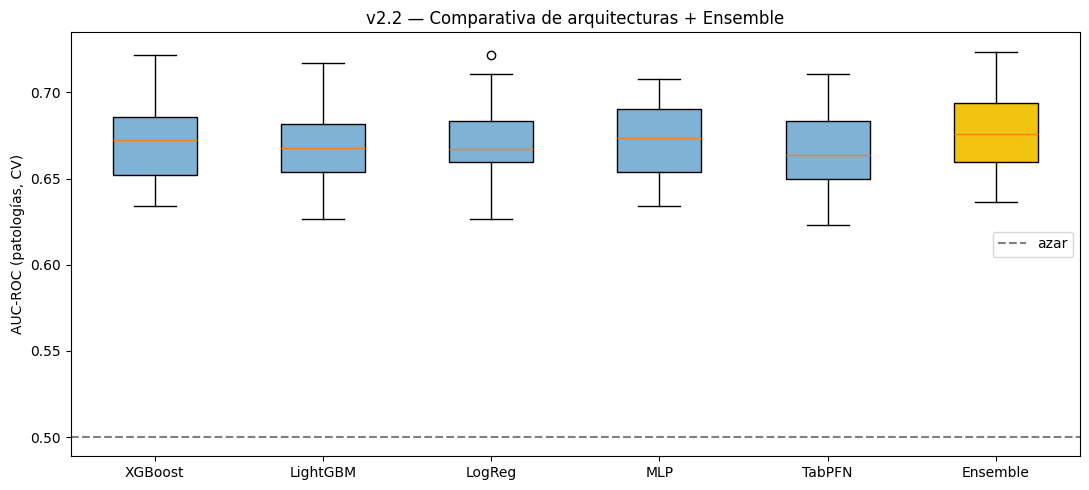

Boxplot guardado.


In [12]:
# CELDA 11 · COMPARATIVA K-FOLD (configs tuneadas) + ENSEMBLE (promedio) + boxplot
BASE_MODELS=["XGBoost","LightGBM","LogReg","MLP"] + (["TabPFN"] if USE_TABPFN else [])
oof={n:np.zeros((len(df_train),N_LABELS),np.float32) for n in BASE_MODELS+["Ensemble"]}
fold_macro={n:[] for n in BASE_MODELS+["Ensemble"]}; perlabel_auc={n:{l:[] for l in LABELS} for n in BASE_MODELS+["Ensemble"]}
failed=set(); kf=KFold(K_COMPARE,shuffle=True,random_state=SEED); t0=time.time()
for k,(tr,va) in enumerate(kf.split(np.arange(len(df_train)))):
    print(f"\n— Fold {k+1}/{K_COMPARE} —")
    imp,sc=dense_fit(tr); Xd_tr=dense_tx(imp,sc,DENSE_tr[tr]); Xd_va=dense_tx(imp,sc,DENSE_tr[va])
    preds_this=[]
    for n in BASE_MODELS:
        if n in failed: continue
        try:
            tk=time.time(); pv=predict_model(n,tr,va,Xd_tr,Xd_va,CFGS); oof[n][va]=pv; preds_this.append(pv)
            mm=multilabel_metrics(pv,y_train[va],m_train[va]); fold_macro[n].append(mm["macro_AUC_path"])
            for l in LABELS: perlabel_auc[n][l].append(mm[l]["AUC"])
            print(f"   {n:9s} macroAUC_path={mm['macro_AUC_path']:.4f} ({(time.time()-tk)/60:.1f} min)")
        except Exception as ex:
            print(f"   ⚠ {n} FALLA y se OMITE: {type(ex).__name__}: {str(ex)[:120]}"); failed.add(n)
    if preds_this:
        ens=np.mean(preds_this,axis=0); oof["Ensemble"][va]=ens
        mm=multilabel_metrics(ens,y_train[va],m_train[va]); fold_macro["Ensemble"].append(mm["macro_AUC_path"])
        for l in LABELS: perlabel_auc["Ensemble"][l].append(mm[l]["AUC"])
        print(f"   {'Ensemble':9s} macroAUC_path={mm['macro_AUC_path']:.4f}")
    gc.collect()
MODELS=[n for n in BASE_MODELS if n not in failed]
print(f"\nComparativa en {(time.time()-t0)/60:.1f} min · Modelos válidos: {MODELS} (+Ensemble)")
ALL=MODELS+["Ensemble"]
print(f"\n{'Modelo':10s} {'macroAUC_path (CV)':>20}"); print("-"*32); rank=[]
for n in ALL:
    print(f"{n:10s} {np.mean(fold_macro[n]):.4f} ± {np.std(fold_macro[n]):.4f}"); rank.append((n,float(np.mean(fold_macro[n]))))
rank.sort(key=lambda x:-x[1]); BEST=rank[0][0]; print(f"\n>>> Mejor: {BEST} (macroAUC_path={rank[0][1]:.4f})")
fig,ax=plt.subplots(figsize=(11,5))
data=[[a for l in PATHOLOGY_LABELS for a in perlabel_auc[n][l] if not np.isnan(a)] for n in ALL]
bp=ax.boxplot(data,labels=ALL,patch_artist=True)
for i,patch in enumerate(bp["boxes"]): patch.set_facecolor("#f1c40f" if ALL[i]=="Ensemble" else "#7fb3d5")
ax.axhline(0.5,color="gray",ls="--",label="azar"); ax.set_ylabel("AUC-ROC (patologías, CV)")
ax.set_title("v2.2 — Comparativa de arquitecturas + Ensemble"); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR/"boxplot_auc_modelos.png",dpi=150,bbox_inches="tight"); plt.show()
print("Boxplot guardado.")


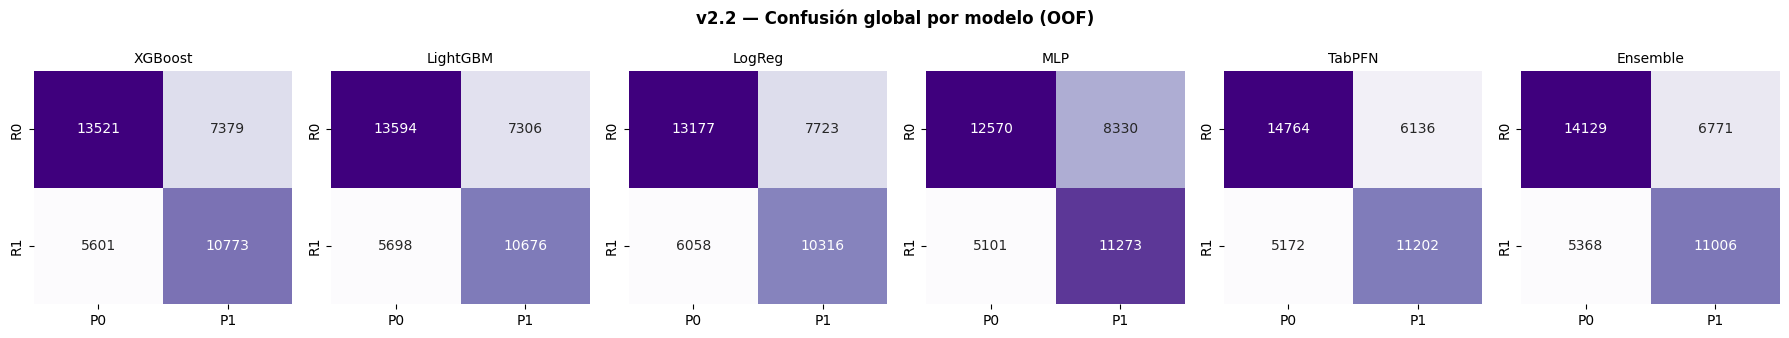

Guardadas.


In [13]:
# CELDA 12 · MATRICES DE CONFUSIÓN POR MODELO (OOF, umbral 0.5)
cols_show=MODELS+["Ensemble"]
fig,axes=plt.subplots(1,len(cols_show),figsize=(3.0*len(cols_show),3.4))
if len(cols_show)==1: axes=[axes]
for ax,n in zip(axes,cols_show):
    yt_all=[]; yp_all=[]
    for j in range(N_LABELS):
        s=m_train[:,j]==1; yt_all.append(y_train[s,j]); yp_all.append((oof[n][s,j]>=0.5).astype(int))
    cm=confusion_matrix(np.concatenate(yt_all),np.concatenate(yp_all),labels=[0,1])
    sns.heatmap(cm,annot=True,fmt="d",cmap="Purples",cbar=False,ax=ax,xticklabels=["P0","P1"],yticklabels=["R0","R1"])
    ax.set_title(n,fontsize=10)
fig.suptitle("v2.2 — Confusión global por modelo (OOF)",fontweight="bold")
plt.tight_layout(); plt.savefig(FIG_DIR/"confusion_por_modelo.png",dpi=150,bbox_inches="tight"); plt.show()
print("Guardadas.")


In [14]:
# CELDA 13 · MEJOR (modelo o ENSEMBLE) ENTRENADO EN FULL TRAIN + TEST
imp_f,sc_f=dense_fit(np.arange(len(df_train)))
Xd_tr_f=dense_tx(imp_f,sc_f,DENSE_tr); Xd_te=dense_tx(imp_f,sc_f,DENSE_te); Xd_vl=dense_tx(imp_f,sc_f,DENSE_vl)
def final_one(name):
    cfg=CFGS.get(name,{})
    if name=="XGBoost": return (ovr_fit_predict(lambda spw: make_xgb(spw,cfg),TREE_tr,y_train,m_train,TREE_te), ovr_fit_predict(lambda spw: make_xgb(spw,cfg),TREE_tr,y_train,m_train,TREE_vl))
    if name=="LightGBM": return (ovr_fit_predict(lambda spw: make_lgb(spw,cfg),TREE_tr,y_train,m_train,TREE_te), ovr_fit_predict(lambda spw: make_lgb(spw,cfg),TREE_tr,y_train,m_train,TREE_vl))
    if name=="LogReg": return (ovr_fit_predict(lambda spw: make_logreg(spw,cfg),Xd_tr_f,y_train,m_train,Xd_te,use_spw=False), ovr_fit_predict(lambda spw: make_logreg(spw,cfg),Xd_tr_f,y_train,m_train,Xd_vl,use_spw=False))
    if name=="MLP":
        c=cfg if cfg else {"lr":8e-4,"dropout":0.3}; mdl,pt=train_mlp(Xd_tr_f,y_train,m_train,Xd_vl,y_val,m_val,c)
        with torch.no_grad():
            mdl.eval(); ptst=torch.sigmoid(mdl(torch.tensor(Xd_te).to(DEVICE))).cpu().numpy()
        return ptst,pt
    if name=="TabPFN":
        sub=np.arange(len(df_train)) if len(df_train)<=TABPFN_MAX_FINAL else np.random.RandomState(SEED).choice(len(df_train),TABPFN_MAX_FINAL,replace=False)
        return (ovr_fit_predict(lambda spw: make_tabpfn(spw),Xd_tr_f[sub],y_train[sub],m_train[sub],Xd_te,use_spw=False), ovr_fit_predict(lambda spw: make_tabpfn(spw),Xd_tr_f[sub],y_train[sub],m_train[sub],Xd_vl,use_spw=False))
    raise ValueError(name)
if BEST=="Ensemble":
    te_list=[]; vl_list=[]
    for n in MODELS:
        try: t_,v_=final_one(n); te_list.append(t_); vl_list.append(v_)
        except Exception as ex: print(f"   {n} omitido en ensemble final: {ex}")
    test_pred=np.mean(te_list,axis=0); val_pred=np.mean(vl_list,axis=0)
else:
    test_pred,val_pred=final_one(BEST)
thr_val=best_thresholds_by_f1(val_pred,y_val,m_val); M=multilabel_metrics(test_pred,y_test,m_test,thresholds=thr_val)
print(f"MEJOR = {BEST}")
print(f"{'Etiqueta':18s} {'AUC':>7} {'AP':>7} {'F1':>7} {'Sens':>6} {'Spec':>6} {'N+':>5} {'N-':>5}"); print("-"*74); rows=[]
for l in LABELS:
    m=M[l]; auc=f"{m['AUC']:.4f}" if not np.isnan(m['AUC']) else "  N/A"
    print(f"{l:18s} {auc:>7} {m['AP']:7.4f} {m['F1']:7.4f} {m['sens']:6.3f} {m['spec']:6.3f} {m['n_pos']:5d} {m['n_neg']:5d}")
    rows.append({"label":l,**{k:m[k] for k in ["AUC","AP","F1","sens","spec","n_pos","n_neg"]}})
print("-"*74); print(f"{'MACRO core':18s} {M['macro_AUC_core']:.4f}  ·  MACRO patol. {M['macro_AUC_path']:.4f}")
pd.DataFrame(rows).to_csv(OUTPUT_DIR/"metrics_best_model.csv",index=False)
json.dump({"best":BEST,"cfgs":CFGS,"test_macro_core":M["macro_AUC_core"],"test_macro_path":M["macro_AUC_path"],"per_label":{l:M[l] for l in LABELS}},
          open(OUTPUT_DIR/"summary_labs_v2_2.json","w",encoding="utf-8"),indent=2,default=str,ensure_ascii=False)
print("Guardados metrics_best_model.csv y summary_labs_v2_2.json")


00:00 Fitting... \

The provided train set hashes match previously uploaded train sets.


00:00 Fitting... Done!
00:00 Predicting... -

The provided test set hash matches a previously uploaded test set.


00:01 Predicting... Done!
00:00 Fitting... -

...

00:01 Predicting... Done!
00:00 Fitting... -

The provided train set hashes match previously uploaded train sets.


00:00 Fitting... Done!
00:00 Predicting... -

The provided test set hash matches a previously uploaded test set.


00:01 Predicting... Done!
MEJOR = Ensemble
Etiqueta               AUC      AP      F1   Sens   Spec    N+    N-
--------------------------------------------------------------------------
Atelectasis         0.6945  0.7336  0.7563  0.957  0.147   141    95
Cardiomegaly        0.6230  0.6416  0.7018  0.972  0.122   144   131
Edema               0.7353  0.4897  0.6000  0.915  0.489    82   182
Lung Opacity        0.7017  0.7527  0.7485  0.954  0.152   131    92
No Finding          0.7006  0.3402  0.3846  0.507  0.777    69   349
Pleural Effusion    0.7044  0.7056  0.6897  0.783  0.500   166   162
--------------------------------------------------------------------------
MACRO core         0.6876  ·  MACRO patol. 0.6918
Guardados metrics_best_model.csv y summary_labs_v2_2.json


In [15]:
# CELDA 13b · EXPORTAR OOF/val/test PARA EL STACKING (formato idéntico al CXR/ECG)
# - oof_train : OOF del modelo elegido (BEST) generado en la CELDA 11 por K-fold (sin fuga) -> entrenar el meta-modelo.
# - val/test  : predicciones del modelo final (full-train) crudas y calibradas (isotónica ajustada en VAL).
# El stacking ya solo tiene que LEER estos 3 CSV (no re-genera el blend de LABS).
from sklearn.isotonic import IsotonicRegression
oof_train_labs = oof["Ensemble"] if BEST=="Ensemble" else oof[BEST]
calibrators={}
for j,l in enumerate(LABELS):
    s=m_val[:,j]==1; yt=y_val[s,j]; yp=val_pred[s,j]
    if len(np.unique(yt))<2: calibrators[l]=None; continue
    iso=IsotonicRegression(out_of_bounds="clip"); iso.fit(yp,yt); calibrators[l]=iso
def apply_cal(p):
    o=p.copy()
    for j,l in enumerate(LABELS):
        if calibrators[l] is not None: o[:,j]=calibrators[l].predict(p[:,j])
    return o
def save_predictions(df, raw, cal, name):
    cols={"hadm_id": df["hadm_id"].to_numpy()}
    for j,l in enumerate(LABELS):
        key=l.replace(" ","_")
        cols[f"labs_{key}"]=raw[:,j]; cols[f"labs_{key}_cal"]=cal[:,j]
    out=pd.DataFrame(cols); path=OUTPUT_DIR/f"labs_pred_{name}.csv"; out.to_csv(path,index=False)
    print(f"   guardado {path}  ({out.shape[0]} filas, {out.shape[1]} cols)"); return out

save_predictions(df_train, oof_train_labs, apply_cal(oof_train_labs), "oof_train")
save_predictions(df_val,   val_pred,       apply_cal(val_pred),       "val")
save_predictions(df_test,  test_pred,      apply_cal(test_pred),      "test")
print(f"OOF/val/test del LABS exportados (modelo={BEST}) -> los carga directamente el stacking.")

   guardado C:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\notebooks\outputs_labs_tabular_v2_2\labs_pred_oof_train.csv  (10000 filas, 13 cols)
   guardado C:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\notebooks\outputs_labs_tabular_v2_2\labs_pred_val.csv  (750 filas, 13 cols)
   guardado C:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\notebooks\outputs_labs_tabular_v2_2\labs_pred_test.csv  (464 filas, 13 cols)
OOF/val/test del LABS exportados (modelo=Ensemble) -> los carga directamente el stacking.


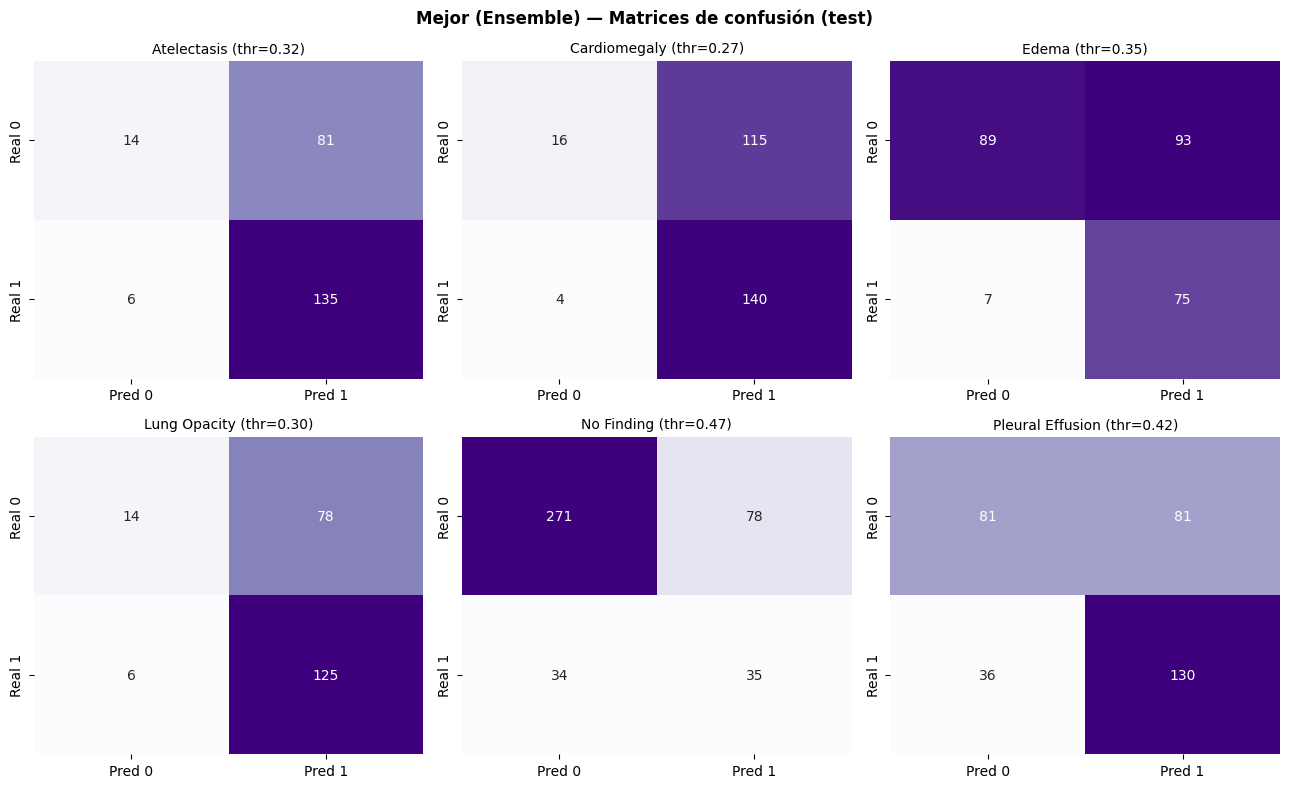

Guardadas.


In [16]:
# CELDA 14 · MATRICES DE CONFUSIÓN DEL MEJOR (test, por etiqueta)
fig,axes=plt.subplots(2,3,figsize=(13,8)); fig.suptitle(f"Mejor ({BEST}) — Matrices de confusión (test)",fontweight="bold")
for j,l in enumerate(LABELS):
    ax=axes[j//3,j%3]; s=m_test[:,j]==1; yt=y_test[s,j]; yp=(test_pred[s,j]>=thr_val.get(l,0.5)).astype(int)
    if len(yt)==0: ax.axis("off"); continue
    cm=confusion_matrix(yt,yp,labels=[0,1])
    sns.heatmap(cm,annot=True,fmt="d",cmap="Purples",cbar=False,ax=ax,xticklabels=["Pred 0","Pred 1"],yticklabels=["Real 0","Real 1"])
    ax.set_title(f"{l} (thr={thr_val.get(l,0.5):.2f})",fontsize=10)
plt.tight_layout(); plt.savefig(FIG_DIR/"confusion_mejor.png",dpi=150,bbox_inches="tight"); plt.show()
print("Guardadas.")


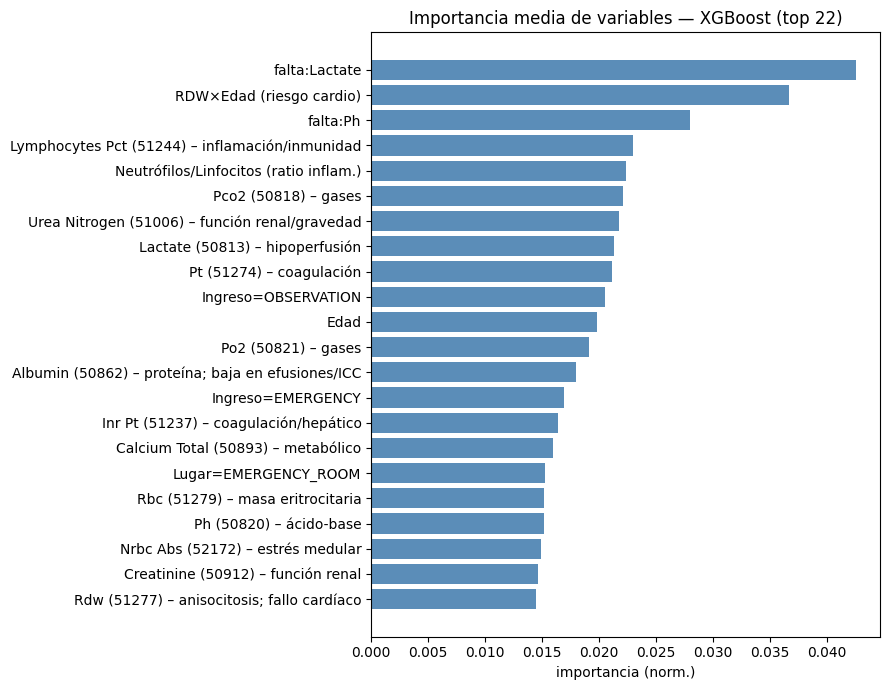

   falta:Lactate                              0.0425
   RDW×Edad (riesgo cardio)                   0.0366
   falta:Ph                                   0.0280
   Lymphocytes Pct (51244) – inflamación/inmunidad 0.0230
   Neutrófilos/Linfocitos (ratio inflam.)     0.0223
   Pco2 (50818) – gases                       0.0221
   Urea Nitrogen (51006) – función renal/gravedad 0.0218
   Lactate (50813) – hipoperfusión            0.0213
   Pt (51274) – coagulación                   0.0211
   Ingreso=OBSERVATION                        0.0205
   Edad                                       0.0198
   Po2 (50821) – gases                        0.0191


In [17]:
# CELDA 15 · IMPORTANCIA DE VARIABLES (XGBoost tuneado, con nombres legibles)
imp=np.zeros(TREE_tr.shape[1])
for j in range(N_LABELS):
    sel=m_train[:,j]==1; yj=y_train[sel,j]
    if len(np.unique(yj))<2: continue
    spw=(yj==0).sum()/max((yj==1).sum(),1); clf=make_xgb(spw,CFGS.get("XGBoost",{})); clf.fit(TREE_tr[sel],yj)
    fi=clf.feature_importances_; imp+=fi/(fi.sum()+1e-9)
imp/=N_LABELS; order=np.argsort(imp)[::-1][:22]
fig,ax=plt.subplots(figsize=(9,7))
ax.barh([TREE_NAMES[i] for i in order][::-1],[imp[i] for i in order][::-1],color="#5b8db8")
ax.set_title("Importancia media de variables — XGBoost (top 22)"); ax.set_xlabel("importancia (norm.)")
plt.tight_layout(); plt.savefig(FIG_DIR/"importancia_variables.png",dpi=150,bbox_inches="tight"); plt.show()
for i in order[:12]: print(f"   {TREE_NAMES[i]:42s} {imp[i]:.4f}")


In [18]:
# CELDA 16 · EQUIDAD POR SUBGRUPO (test)
dft=df_test.reset_index(drop=True)
for col,lab in [("gender","GÉNERO"),("race","RAZA"),("admission_type","INGRESO")]:
    if col not in dft.columns: continue
    print(f"\n-- AUC macro (patologías) por {lab} --")
    for v in sorted(dft[col].dropna().unique(),key=str):
        idx=dft.index[dft[col]==v].to_numpy()
        if len(idx)<15: print(f"   {str(v):22s} n={len(idx):4d} (insuficiente)"); continue
        mm=multilabel_metrics(test_pred[idx],y_test[idx],m_test[idx]); print(f"   {str(v):22s} n={len(idx):4d}  macroAUC_path={mm['macro_AUC_path']:.4f}")
print("\nEquidad completada.")



-- AUC macro (patologías) por GÉNERO --
   0                      n= 184  macroAUC_path=0.6720
   1                      n= 280  macroAUC_path=0.7017

-- AUC macro (patologías) por RAZA --
   ASIAN                  n=  15  macroAUC_path=0.8133
   BLACK                  n=  58  macroAUC_path=0.5706
   HISPANIC_LATINO        n=  21  macroAUC_path=0.6226
   OTHER_KNOWN            n=   3 (insuficiente)
   UNKNOWN                n=  52  macroAUC_path=0.6480
   WHITE                  n= 315  macroAUC_path=0.7204

-- AUC macro (patologías) por INGRESO --
   EMERGENCY              n= 322  macroAUC_path=0.6479
   OBSERVATION            n=  66  macroAUC_path=0.7858
   SCHEDULED              n=  34  macroAUC_path=0.6236
   URGENT                 n=  42  macroAUC_path=0.7170

Equidad completada.


---
## ✅ Conclusión — Módulo tabular v2.2

Exprimido al máximo dentro del techo de la señal tabular: **ratios clínicos** (BUN/Creatinina, Neutrófilos/Linfocitos,
RDW×Edad), **tuning de los 4 modelos** con Optuna, **K=5 sin leakage**, y un **ensemble por promedio** que suele ser el
mejor resultado. Mantiene negativos derivados de *No Finding*, masking intacto, desequilibrio por etiqueta y métricas
honestas. La importancia se reporta sobre XGBoost (tuneado) con nombres legibles. Recordatorio: el valor real del módulo
tabular es como **modalidad complementaria** en una futura fusión, no en solitario.
